In [20]:
# print("hello")

In [21]:
import idx2numpy
import numpy as np
import matplotlib.pyplot as plt

In [22]:
#Loading the training images and labels
X_train = idx2numpy.convert_from_file('train-images.idx3-ubyte')
y_train = idx2numpy.convert_from_file('train-labels.idx1-ubyte')

#Loading the test images and labels
X_test = idx2numpy.convert_from_file('t10k-images.idx3-ubyte')
y_test = idx2numpy.convert_from_file('t10k-labels.idx1-ubyte')


In [23]:
filter=np.isin(y_train,[0,1,2])
test_filter = np.isin(y_test,[0,1,2])



X_filtered = X_train[filter]
y_filtered = y_train[filter]


X_test_filtered = X_test[test_filter]
y_test_filtered = y_test[test_filter]



In [24]:
def sample_data(X,y):
    
    np.random.seed(0)  # setting the seed for fixed random sampling so that accracy doent change every time
    
    selected_indices=[]
    
    
    for digit in [0,1,2]:
        available_indices = np.where(y==digit)[0]  #it returns a tuple

        chosen_indices = np.random.choice(available_indices,100,replace=False)  #replace=False no duplicate
        
        # append to list
        selected_indices.extend(chosen_indices)
    
    selected_indices=np.sort(selected_indices)
    
  
    X_sampled=X[selected_indices]
    y_sampled=y[selected_indices]
    
    return X_sampled, y_sampled



# Apply sampling
X_train_sampled,y_train_final=sample_data(X_filtered, y_filtered)
X_test_sampled,y_test_final=sample_data(X_test_filtered, y_test_filtered)



In [25]:
def converrt(x):
    my_array = np.zeros((784, 300))
    for i in range(300):
        k=0
        for j in range(784):
            dj=j%28
            k=j//28
            my_array[j][i]=x[i][dj][k]/255.0
            
    return my_array



X_train_final=converrt(X_train_sampled)
X_test_final=converrt(X_test_sampled)

print(X_train_final.shape)


(784, 300)


## Finding cov and Mean

In [26]:
mean=np.zeros((784,1))

for i in range(784):
    sum=0
    for j in range(300):
        sum+=X_train_final[i][j]
    mean[i][0]=sum/300    #100 is the class size

X_c=X_train_final-mean

sigma=(X_c @ X_c.T)/(300-1)

identity=np.eye(784)



## Finding eigen val and vectors

In [27]:
eigenvalues,eigenvectors=np.linalg.eigh(sigma)

print(eigenvalues.shape)
print(eigenvectors.shape)

eig=[]

for i in range(784):
    eig.append((eigenvalues[i],eigenvectors[:,i]))



eig.sort(key=lambda x: x[0], reverse=True)


sor_values=np.sort(eigenvalues)[::-1]

tot_sum=np.sum(eigenvalues)
ret= tot_sum*0.75  # Retaining 75% variance

p=0
curr_sum=0
while(p<784 and curr_sum<ret):
    curr_sum+=sor_values[p]
    p+=1

print("No. of components : ",p)


U=eig[0][1].reshape(-1, 1)


for i in range(1,p):
    new_col = eig[i][1].reshape(-1, 1)
    U = np.hstack((U, new_col))

print(U.shape)
    

(784,)
(784, 784)
No. of components :  20
(784, 20)


## Obtaining the projected centered matrix

In [28]:
Y = U.T @ X_c

print(Y)

[[ 3.32063123 -3.84620924 -0.32268463 ... -3.37701265 -3.3975793
  -3.47242095]
 [-2.27821048  0.04826213  2.82229829 ... -0.15127631 -0.06814398
  -0.23165374]
 [-0.24825188 -0.34372019 -0.42975887 ...  0.39370532  0.27519073
   0.33372669]
 ...
 [ 1.10168156  0.56303022 -1.04041298 ...  0.16607768  0.23307376
  -0.04795927]
 [-1.1472078   0.27799412  0.05658675 ...  0.49032152  0.34255781
  -0.21434441]
 [ 0.67004651  0.39948171 -0.40961419 ...  0.63656925  0.67925092
  -0.17212892]]


## Showing Projection and error for test points

In [29]:
X_test_5 = X_test_final[:, :5] 


# centring the test points
X_test_5_c = X_test_5 - mean

# project
Y_test_5 =U.T@X_test_5_c

X_reconstructed=(U @ Y_test_5)+mean

for i in range(5):
    orig_sample=X_test_5[:, i]
    reconstructed_sample=X_reconstructed[:, i]
    
    
    sample_mse=np.mean((orig_sample-reconstructed_sample)**2)
    print("Mean squared error for sample",i+1,": ",sample_mse)

Mean squared error for sample 1 :  0.035347591959726095
Mean squared error for sample 2 :  0.009708750921967397
Mean squared error for sample 3 :  0.025907762964452085
Mean squared error for sample 4 :  0.030834631360757824
Mean squared error for sample 5 :  0.028462992698232523


## Displaying original and reonstructed images

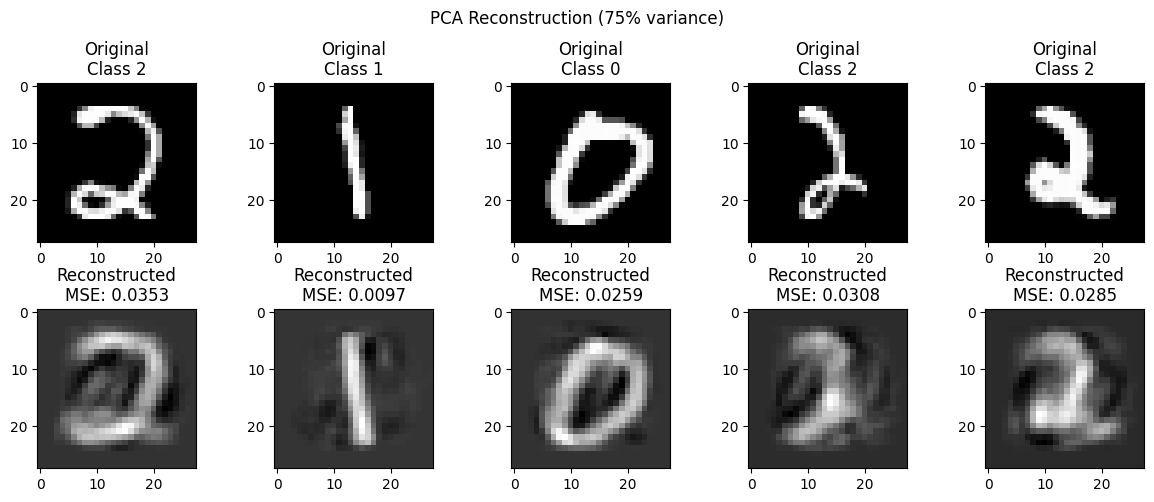

In [30]:

fig, axes = plt.subplots(2,5,figsize=(12,5))

for i in range(5):
    orig_sample=X_test_5[:, i]
    recon_sample = X_reconstructed[:, i]
    
    mse=np.mean((orig_sample - recon_sample)**2)
    
    # to get oringinal image reshaping
    axes[0, i].imshow(orig_sample.reshape(28,28,order='F'),cmap='gray')
    axes[0, i].set_title(f"Original\nClass {y_test_final[i]}")
    
    
    # Reconstructed image
    axes[1, i].imshow(recon_sample.reshape(28, 28, order='F'), cmap='gray')
    axes[1, i].set_title(f"Reconstructed\nMSE: {mse:.4f}")
    

plt.suptitle("PCA Reconstruction (75% variance)", fontsize=12)
plt.tight_layout()
plt.show()

## LDA for reduced space

In [31]:

def run_lda(U,mean, X_train_final, y_train_final, X_test_final, y_test_final, p):
    
    parameters ={}

    X_train_centered = X_train_final - mean
    X_test_centered = X_test_final - mean

    # Project the centered data
    Y_train = U.T @ X_train_centered
    Y_test = U.T @ X_test_centered

    for digit in [0,1,2]:
        indx=np.where(y_train_final == digit)[0]

        class_data= Y_train[:, indx]

        cls_mean=np.zeros((p,1))

        for i in range(p):
            sum=0
            for j in range(100):
                sum+=class_data[i][j]
            cls_mean[i][0]=sum/100    #100 is the class size

        X_cntr=class_data-cls_mean

        sig = (X_cntr @ X_cntr.T) / 100

        # print(mean.shape)
        # print(sig.shape)

        parameters[digit]={"mean":cls_mean,"covariance":sig}

    def isinvertible(sigma):
        rank=np.linalg.matrix_rank(sigma)
        if rank<p:
            return False
        return True

    # not considering priors in disciminant calculation bcz all are same = 0.33
    def discriminant(meu,x_i,sigma_inv):
        omega= sigma_inv @ meu

        omega_t=omega.T

        b= -(meu.T@sigma_inv@meu)/2

        return (omega_t@ x_i+b).item()

    def lda(sigma,y_data,y_true):
        if(not isinvertible(sigma)):
            sigma +=0.0001*np.identity(p)

        sigma_inv = np.linalg.inv(sigma)
        tot=0

        d={}
        prediction=[]
        for i in range(300):
            x_i = y_data[:,i]
            for j in parameters:
                meu = parameters[j]["mean"]
                d[j]=discriminant(meu,x_i,sigma_inv)
            mx=-np.inf
            cls=-1
            for c,scor in d.items():
                if(scor>mx):
                    cls=c
                    mx=scor
            prediction.append(cls)
            if y_true[i]==cls:
                tot+=1
        return prediction,tot

    # here i am taking the common covariance matrix as mean of all the matrices.
    sigma = (parameters[0]["covariance"]+parameters[1]["covariance"]+parameters[2]["covariance"])/3



    predicted_LDA,total_eq=lda(sigma,Y_train,y_train_final)

    # print(predicted_LDA)
    accuracy = total_eq/300


    
    print("Train Accuracy: ", accuracy) # 300   as 300 are the total samples



    predicted_LDA,total_eq=lda(sigma,Y_test,y_test_final)

    # print(predicted_LDA)
    accuracy = total_eq/300
    print("Test Accuracy: ", accuracy) # 300   as 300 are the total samples


    
    return predicted_LDA, accuracy, parameters

print("PCA+LDA Accuracy for 75% variance")

predictions_LDA, acc_LDA, lda_params = run_lda(U,mean, X_train_final, y_train_final, X_test_final, y_test_final, p)

PCA+LDA Accuracy for 75% variance
Train Accuracy:  0.9733333333333334
Test Accuracy:  0.9766666666666667


## QDA for reduced space

In [32]:
def run_QDA(U,mean, X_train_final, y_train_final, X_test_final, y_test_final, p):

    parameters ={}

    X_train_centered=X_train_final - mean
    X_test_centered=X_test_final - mean

    
    Y_train=U.T @ X_train_centered
    Y_test=U.T @ X_test_centered

    for digit in [0,1,2]:
        indx=np.where(y_train_final==digit)[0]

        class_data= Y_train[:, indx]

        cls_mean=np.zeros((p,1))

        for i in range(p):
            sum=0
            for j in range(100):
                sum+=class_data[i][j]
            cls_mean[i][0]=sum/100    #100 is the class size

        X_cntr=class_data-cls_mean

        sig = (X_cntr @ X_cntr.T) / 100

        # print(mean.shape)
        # print(sig.shape)

        parameters[digit]={"mean":cls_mean,"covariance":sig}





    def isinvertible(sigma):
        rank = np.linalg.matrix_rank(sigma)
        if rank<p:
            return False
        return True


# not considering priors in disciminant calculation bcz all are same = 0.33
    def discriminant(sigma,meu,x_i,sigma_inv):
        sign,sigma_log_det=np.linalg.slogdet(sigma)
        omega= sigma_inv @ meu
        W=-sigma_inv/2

        omega_t=omega.T

        b= (-(meu.T @ sigma_inv @ meu)/2)-(sigma_log_det/2)
        return (x_i.T @ W @ x_i+ omega_t @ x_i + b).item()



    # finding inverse
    stats={}

    for j in parameters:
        sigma = parameters[j]["covariance"].copy()
        if(not isinvertible(sigma)):
            sigma +=0.0001*np.identity(p)
        parameters[j]["covariance"]=sigma
        sigma_inv = np.linalg.inv(sigma)
        stats[j]=sigma_inv

        


    def qda(y_data,y_true):
        
        d={}
        tot=0
        prediction=[]
        for i in range(300):
            for j in parameters:
                x_i = y_data[:,i].reshape(-1, 1)
                meu = parameters[j]["mean"]
                sigma = parameters[j]["covariance"].copy()
                sigma_inv=stats[j]
                d[j]=discriminant(sigma,meu,x_i,sigma_inv)
            mx=-np.inf
            cls=-1
            for c,scor in d.items():
                if(scor>mx):
                    cls=c
                    mx=scor
            if y_true[i]==cls:
                tot+=1
            prediction.append(cls)
        return prediction,tot

    

    predicted_QDA,total_eq=qda(Y_train,y_train_final)
    print("Train Accuracy: ",total_eq/300) # 300 as 300 are the total samples




    predicted_QDA,total_eq=qda(Y_test,y_test_final)

    # print(predicted_QDA)

    print("Test Accuracy: ",total_eq/300) # 300 as 300 are the total samples

    return predicted_QDA, total_eq/300, parameters, stats

print("PCA+QDA Accuracy for 75% variance")

predictions_QDA, acc_QDA, qda_params, qda_stats=run_QDA(U,mean,X_train_final,y_train_final, X_test_final, y_test_final, p)

PCA+QDA Accuracy for 75% variance
Train Accuracy:  1.0
Test Accuracy:  0.96


## Tests on sample point

In [33]:
print("PCA+LDA with 75 % var scores of a samples test point")
sample_idx = 0


x_sample_centered = X_test_final[:, sample_idx].reshape(-1, 1)-mean
y_sample = U.T @ x_sample_centered
true_cls = y_test_final[sample_idx]

# LDA TST
print(f"\n[LDA Scores] (True Label: {true_cls})")


sigma_lda=(lda_params[0]["covariance"] + lda_params[1]["covariance"] + lda_params[2]["covariance"]) / 3


if np.linalg.matrix_rank(sigma_lda) < p:
    sigma_lda += 0.0001 * np.identity(p)
sigma_inv_lda = np.linalg.inv(sigma_lda)

# Calculate scores
for cls in [0, 1, 2]:
    mu = lda_params[cls]["mean"]
    
   
    omega = sigma_inv_lda @ mu
    b = -(mu.T @sigma_inv_lda@ mu) / 2
    score = (omega.T @ y_sample+b).item()
    
    print(f"Class {cls} Score: {score:.4f}")




# QDA TST
print(f"\n[QDA Scores] (True Label: {true_cls})")

# Calculate scores
for cls in [0, 1, 2]:
    mu = qda_params[cls]["mean"]
    sigma_inv_qda = qda_stats[cls]
    sigma_qda = qda_params[cls]["covariance"]
    
 
    if np.linalg.matrix_rank(sigma_qda) < p:
        sigma_qda += 0.0001 * np.identity(p)
    
    
    sign,sigma_log_det = np.linalg.slogdet(sigma_qda)
    omega=sigma_inv_qda @ mu
    W= -sigma_inv_qda /2
    b = (-(mu.T @ sigma_inv_qda @ mu) / 2) - (sigma_log_det / 2)
    
    score = (y_sample.T @ W @ y_sample + omega.T @ y_sample + b).item()
    
    print(f"Class {cls} Score: {score:.4f}")



print("\nSo here LDA/QDA will label to classes with max scores")

PCA+LDA with 75 % var scores of a samples test point

[LDA Scores] (True Label: 2)
Class 0 Score: -8.6917
Class 1 Score: -11.3542
Class 2 Score: 0.3403

[QDA Scores] (True Label: 2)
Class 0 Score: -39.4737
Class 1 Score: -1222.2681
Class 2 Score: -11.4899

So here LDA/QDA will label to classes with max scores


## Acuracy with 90% var

In [34]:
ret_dash = tot_sum*0.90  # Retaining 90% variance

p_dash=0
curr_sum=0
while(p_dash<784 and curr_sum<ret_dash):
    curr_sum+=sor_values[p_dash]
    p_dash+=1


U_dash=eig[0][1].reshape(-1, 1)


for i in range(1,p_dash):
    new_col = eig[i][1].reshape(-1, 1)
    U_dash = np.hstack((U_dash, new_col))



print("No. of components : ",p_dash,"\n")

print("PCA+LDA Accuracy for 90% variance")

predictions_LDA, acc_LDA, lda_params = run_lda(U_dash,mean, X_train_final, y_train_final, X_test_final, y_test_final, p_dash)

print("\n")

print("PCA+QDA Accuracy for 90% variance")
predictions_QDA, acc_QDA, qda_params, qda_stats = run_QDA(U_dash,mean, X_train_final, y_train_final, X_test_final, y_test_final, p_dash)


No. of components :  51 

PCA+LDA Accuracy for 90% variance
Train Accuracy:  0.99
Test Accuracy:  0.9666666666666667


PCA+QDA Accuracy for 90% variance
Train Accuracy:  1.0
Test Accuracy:  0.94


## Accuracy by using only first 2 principle components

In [35]:
p_dash=2

U_dash=eig[0][1].reshape(-1, 1)


# for i in range(1,p_dash):
new_col = eig[1][1].reshape(-1, 1)
U_dash = np.hstack((U_dash, new_col))

print("PCA+LDA Accuracy using only first 2 components")

predictions_LDA, acc_LDA, lda_params = run_lda(U_dash,mean, X_train_final, y_train_final, X_test_final, y_test_final, p_dash)

print("\n")
print("PCA+QDA Accuracy using only first 2 components")

predictions_QDA, acc_QDA, qda_params, qda_stats = run_QDA(U_dash,mean, X_train_final, y_train_final, X_test_final, y_test_final, p_dash)

PCA+LDA Accuracy using only first 2 components
Train Accuracy:  0.9066666666666666
Test Accuracy:  0.9333333333333333


PCA+QDA Accuracy using only first 2 components
Train Accuracy:  0.95
Test Accuracy:  0.9266666666666666


# FDA

In [36]:
parameters ={}

for digit in [0,1,2]:
    indx=np.where(y_train_final == digit)[0]

    class_data= X_train_final[:, indx]

    cls_mean=np.zeros((784,1))

    for i in range(784):
        sum=0
        for j in range(100):
            sum+=class_data[i][j]
        cls_mean[i][0]=sum/100    #100 is the class size


     

    X_cntr=class_data-cls_mean

    sig = (X_cntr @ X_cntr.T) / 100

    # print(mean.shape)
    # print(sig.shape)

    parameters[digit]={"mean":cls_mean,"covariance":sig}

S_b=np.zeros((784,784))
S_w=np.zeros((784,784))

for i in range(3):
    mean_cnt = parameters[i]["mean"]-mean

    S_b+=100 * (mean_cnt @ mean_cnt.T)
    S_w+=100 * parameters[i]["covariance"]


def isinvertible(sigma):
        rank = np.linalg.matrix_rank(sigma)
        if rank<784:
            return False
        return True


S_w_reg=S_w

if(not isinvertible(S_w)):
    S_w_reg = S_w + 0.0001 * np.identity(784)



S_w_inv = np.linalg.inv(S_w_reg)
mat = S_w_inv @ S_b




eigenvalues_fda, eigenvectors_fda = np.linalg.eigh(mat)

# taking only real parts
eigenvalues_fda = np.real(eigenvalues_fda)
eigenvectors_fda = np.real(eigenvectors_fda)

# sort in descending order eigenvalue
index_srted_vals = np.argsort(eigenvalues_fda)[::-1]  #give the index wrt sorted eigen values
srted_vals = eigenvalues_fda[index_srted_vals]
srted_vect = eigenvectors_fda[:, index_srted_vals]

W = srted_vect[:, :2] #using 2 eigen vec corresponding to 2 highest eigen vals

## LDA QDA for FDA

In [37]:
W = np.real(W)
print("FDA+LDA")
predictions_LDA_fda, acc_LDA_fda, lda_params_fda = run_lda(W,mean,X_train_final, y_train_final, X_test_final, y_test_final,2)


print("\nFDA+QDA")
predictions_QDA_fda, acc_QDA_fda, qda_params_fda, qda_stats_fda = run_QDA(W,mean,X_train_final, y_train_final, X_test_final, y_test_final, 2)

FDA+LDA
Train Accuracy:  0.9533333333333334
Test Accuracy:  0.9566666666666667

FDA+QDA
Train Accuracy:  0.9666666666666667
Test Accuracy:  0.9566666666666667


# Plotting

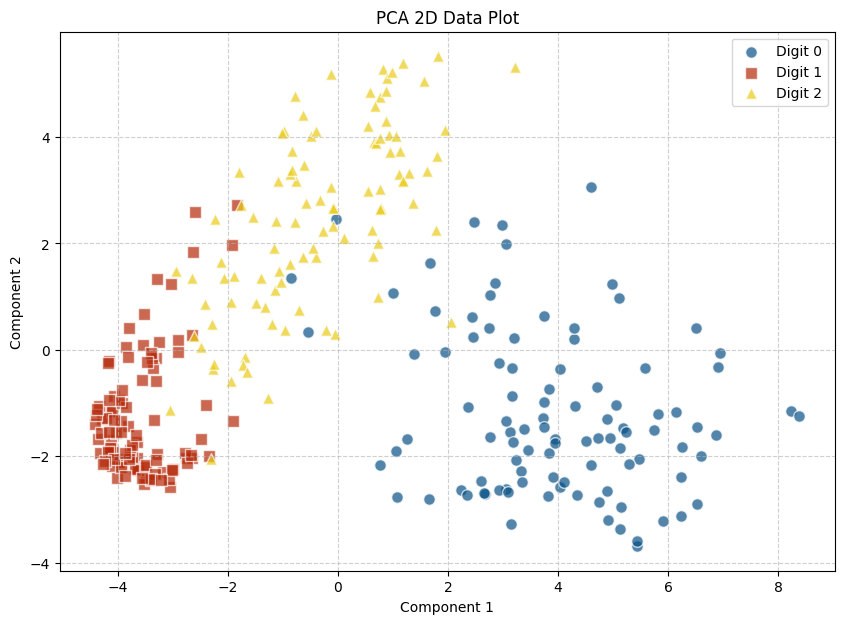

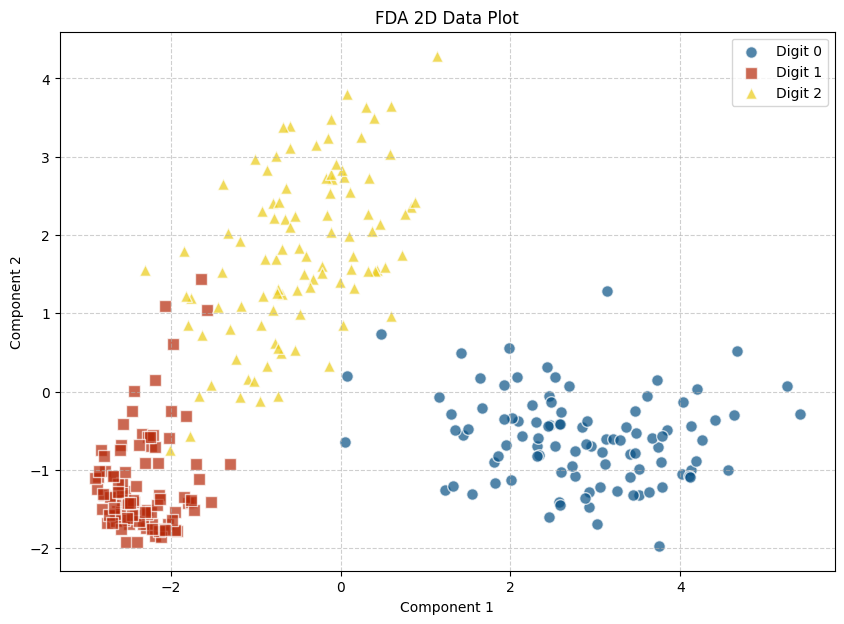

In [38]:

def plot_2d(data_2d, cls, title, xlabel, ylabel):
    X_proj = data_2d.T 
    
    plt.figure(figsize=(10,7))
    colors = ["#095185", "#b52809", "#EBCB15"] # Your custom colors
    markers = ['o', 's', '^']                  # Added markers for the assignment requirement
    
    for digit in [0, 1, 2]:
        indx = (cls == digit)
        plt.scatter(X_proj[indx, 0], X_proj[indx, 1],label=f"Digit {digit}",edgecolors='w',color=colors[digit],marker=markers[digit], s=70, alpha=0.7)
    
    plt.title(title)
    plt.legend()
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


Y_pca_2d = U_dash.T @ (X_train_final - mean)
plot_2d(Y_pca_2d, y_train_final, "PCA 2D Data Plot", "Component 1", "Component 2")



Y_fda_2d = W.T @ (X_train_final - mean)
plot_2d(Y_fda_2d, y_train_final, "FDA 2D Data Plot", "Component 1", "Component 2")